- Tiếp tục sử dụng file data đã xử lí để tiến hành huấn luyện và đánh giá mô hình.

In [ ]:
# import thư viện
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv('C:\GIT\GROUP__3\DATA\processed_data.csv')

In [3]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,age_group_encoded,bmi_category,bmi_category_encoded
0,1,67,0,1,1,3,1,228.69,36.600000,0,1,60+,4,Obese,1
1,0,61,0,0,1,4,0,202.21,28.893237,1,1,60+,4,Over_weight,2
2,1,80,0,1,1,3,0,105.92,32.500000,1,1,60+,4,Obese,1
3,0,49,0,0,1,3,1,171.23,34.400000,2,1,46-60,3,Obese,1
4,0,79,1,0,1,4,0,174.12,24.000000,1,1,60+,4,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5059,0,80,1,0,1,3,1,83.75,28.893237,1,0,60+,4,Over_weight,2
5060,0,81,0,0,1,4,1,125.20,40.000000,1,0,60+,4,Obese,1
5061,0,35,0,0,1,4,0,82.99,30.600000,1,0,31-45,2,Obese,1
5062,1,51,0,0,1,3,0,166.29,25.600000,0,0,46-60,3,Over_weight,2


In [5]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke', 'age_group', 'age_group_encoded',
       'bmi_category', 'bmi_category_encoded'],
      dtype='object')


In [6]:
print(df.dtypes)

gender                    int64
age                       int64
hypertension              int64
heart_disease             int64
ever_married              int64
work_type                 int64
Residence_type            int64
avg_glucose_level       float64
bmi                     float64
smoking_status            int64
stroke                    int64
age_group                object
age_group_encoded         int64
bmi_category             object
bmi_category_encoded      int64
dtype: object


In [7]:
# chọn các cột số
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("numeric_cols:", numerical_cols)

numeric_cols: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'age_group_encoded', 'bmi_category_encoded']


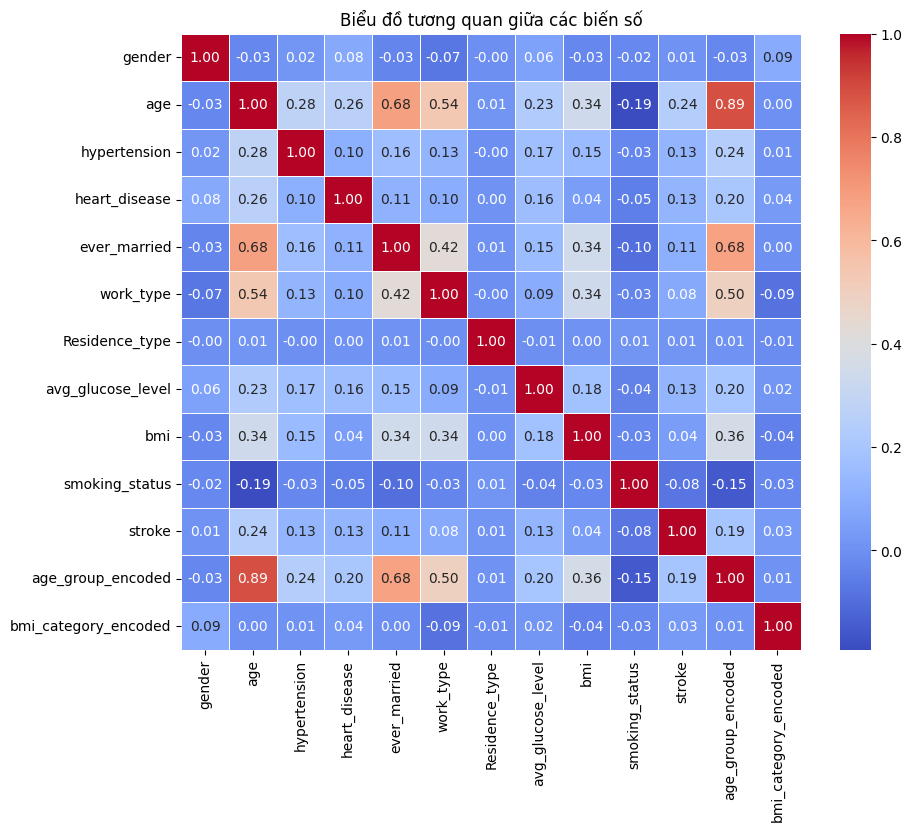

In [ ]:
# Tính ma trận tương quan
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Biểu đồ tương quan giữa các biến số")
plt.show()

In [ ]:
df['stroke'].value_counts().reset_index(name='count').rename(columns={'index': 'stroke'})   # kiểm tra nhãn.

,stroke,count
0,0,4820
1,1,244


In [ ]:
# Biến mục tiêu
target = 'stroke'

# Biến đầu vào
features = ['gender', 'age', 'hypertension', 'heart_disease',
            'ever_married', 'work_type', 'Residence_type',
            'avg_glucose_level', 'bmi', 'smoking_status',
            'age_group_encoded', 'bmi_category_encoded']

X = df[features]
y = df[target]

# train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Decision Tree

In [ ]:
# Huấn luyện model với tiêu chí "entropy"
tree_model = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42)
tree_model.fit(X_train, y_train)

# Lấy độ quan trọng của các đặc trưng
importances = tree_model.feature_importances_

# Gắn lại với tên cột
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                 Feature  Importance
7      avg_glucose_level    0.314258
1                    age    0.293848
8                    bmi    0.214961
9         smoking_status    0.040705
5              work_type    0.033652
0                 gender    0.029772
4           ever_married    0.019214
6         Residence_type    0.015247
2           hypertension    0.010162
10     age_group_encoded    0.009947
3          heart_disease    0.009123
11  bmi_category_encoded    0.009111


D:\temp\ipykernel_13828\2889819433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


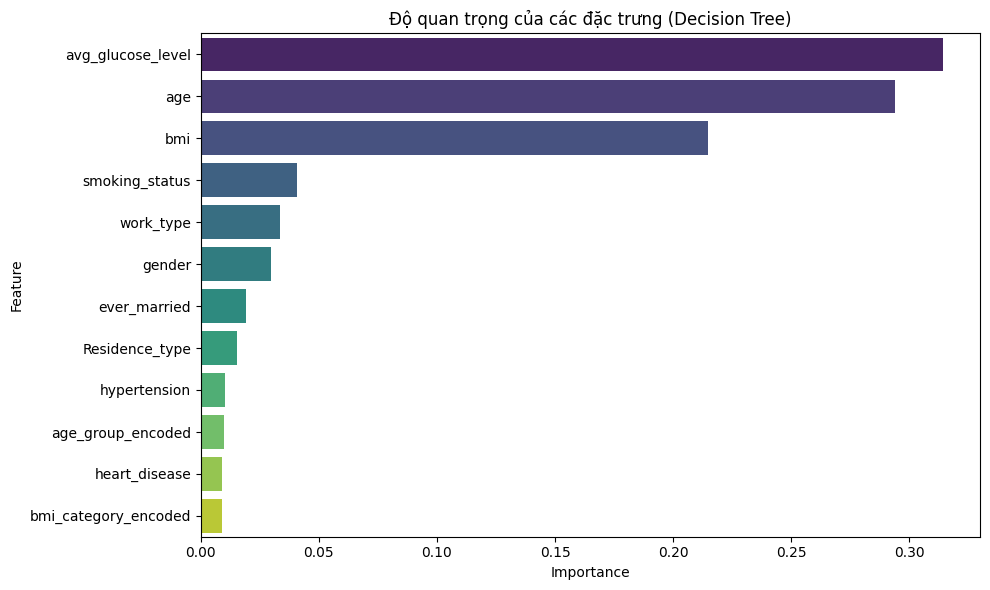

In [ ]:
#Biểu đồ độ quan trọng của các đặc trưng
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Độ quan trọng của các đặc trưng (Decision Tree)")
plt.tight_layout()
plt.show()

In [ ]:
# Lọc đặc trưng quan trọng (>2% đóng góp)
selected_features = feature_importance_df[feature_importance_df['Importance'] > 0.02]['Feature'].tolist()

# Tạo tập dữ liệu mới chỉ với các đặc trưng này
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [16]:
# Huấn luyện lại với đặc trưng quan trọng
tree_model_selected = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42)
tree_model_selected.fit(X_train_selected, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
# Dự đoán
y_pred = tree_model_selected.predict(X_test_selected)
y_prob = tree_model_selected.predict_proba(X_test_selected)[:, 1]  # xác suất class=1

# Đánh giá
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       964
           1       0.15      0.16      0.16        49

    accuracy                           0.92      1013
   macro avg       0.55      0.56      0.56      1013
weighted avg       0.92      0.92      0.92      1013

ROC AUC Score: 0.5582924040985688


Thêm lưới tham số param_grid

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring='f1', n_jobs=-1)

grid_search.fit(X_train_selected, y_train)

print("Best parameters:", grid_search.best_params_)
best_tree = grid_search.best_estimator_

Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [ ]:
y_pred_best = best_tree.predict(X_test_selected)
y_prob_best = best_tree.predict_proba(X_test_selected)[:, 1]

print("Classification Report (Best Tree):\n", classification_report(y_test, y_pred_best))
print("ROC AUC Score (Best Tree):", roc_auc_score(y_test, y_prob_best))

Classification Report (Best Tree):
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       964
           1       0.14      0.10      0.12        49

    accuracy                           0.93      1013
   macro avg       0.55      0.53      0.54      1013
weighted avg       0.92      0.93      0.92      1013

ROC AUC Score (Best Tree): 0.5730480989076129


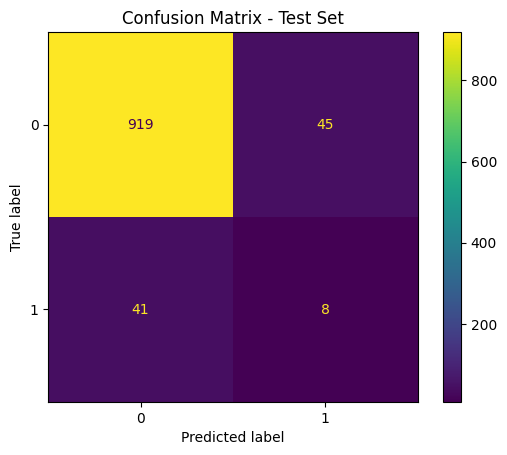

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

**Nhận xét:**

**Mô hình 1: Cây quyết định cơ bản (Decision Tree)**
- **Accuracy**: 92%
- **F1-score (stroke=1)**: 0.16
- **Recall (stroke=1)**: 0.16
- **ROC AUC**: 0.558

Mô hình có độ chính xác tổng thể cao nhưng chỉ phát hiện **16% ca đột quỵ**. Khả năng phân biệt giữa hai lớp còn yếu.

---

**Mô hình 2: Cây quyết định sau tối ưu hóa tham số (GridSearchCV)**
- **Accuracy**: 93%
- **F1-score (stroke=1)**: 0.12
- **Recall (stroke=1)**: 0.10
- **ROC AUC**: 0.573

Sau khi dùng GridSearch, mô hình **tăng nhẹ ROC AUC**, nhưng lại **giảm khả năng phát hiện đột quỵ** (recall giảm xuống 10%).

---

Kết luận
- Cả hai mô hình đều bị ảnh hưởng nặng bởi mất cân bằng nhãn.
- Việc tối ưu tham số chưa mang lại cải thiện đáng kể cho lớp thiểu số (`stroke=1`).
- Cần chuyển sang mô hình mạnh hơn (Random Forest,...) **kết hợp với kỹ thuật như SMOTE hoặc scale_pos_weight** để cải thiện recall class 1.